In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าให้กราฟแสดงผลสวยงาม
sns.set_theme(style="whitegrid")

# 1. โหลดข้อมูล (เปลี่ยนชื่อไฟล์ให้ตรงกับที่คุณอัปโหลด)
df_bookings = pd.read_csv('fact_bookings_5000.csv')
df_marketing = pd.read_csv('fact_marketing_spend.csv')

# ดูตัวอย่างข้อมูลเบื้องต้น
print("โหลดข้อมูลสำเร็จ!")
df_bookings.head()

โหลดข้อมูลสำเร็จ!


,booking_id,booking_date,checkin_date,channel_id,Channel Name,rate_code,gross_revenue,Commission Rate,commission_amount,net_revenue,booking_status
0,1,29/10/2025,3/11/2025,1,#REF!,RACK,"4,102.00",#REF!,6.86,"4,547.69",confirmed
1,2,12/10/2025,13/10/2025,2,#REF!,FLASH,"6,418.10",#REF!,919.95,912.01,confirmed
2,3,31/10/2025,2/11/2025,4,#REF!,PROMO20,"3,729.00",#REF!,225.28,"2,891.36",confirmed
3,4,28/11/2025,2/12/2025,3,#REF!,PROMO20,0.00,#REF!,89.68,0.00,cancelled
4,5,12/10/2025,14/10/2025,3,#REF!,RACK,"4,626.90",#REF!,"4,128.34","3,395.31",confirmed


✅ โหลดข้อมูลสำเร็จ! กำลังทำความสะอาดและประมวลผลกราฟ...


/tmp/ipykernel_2467/1329655195.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=net_adr_by_channel, x='Channel Name', y='Net_ADR', palette='viridis')


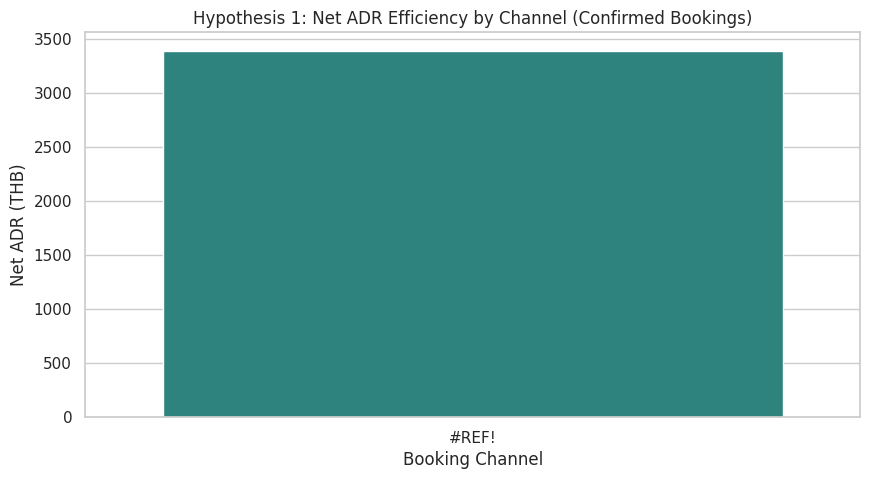

/tmp/ipykernel_2467/1329655195.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=finance_summary, x='Channel Name', y='COA_Percent', palette='magma')


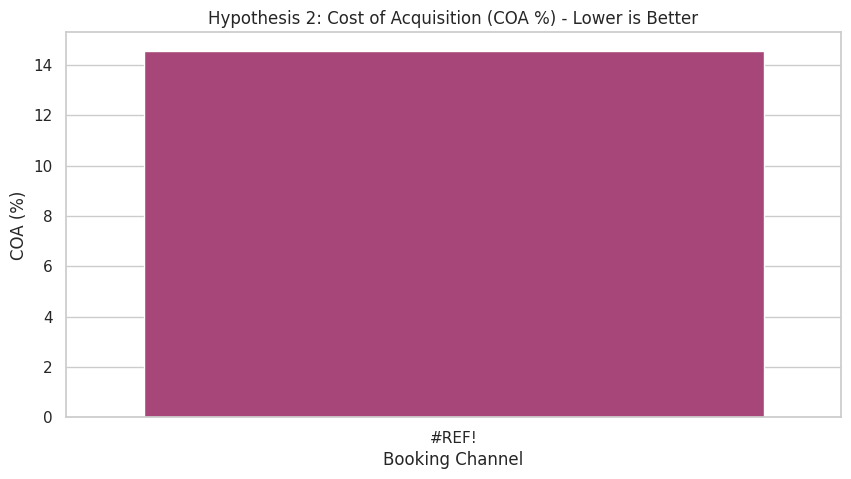

/tmp/ipykernel_2467/1329655195.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=status_counts, x='Channel Name', y='Cancellation_Rate_Percent', palette='Reds_r')


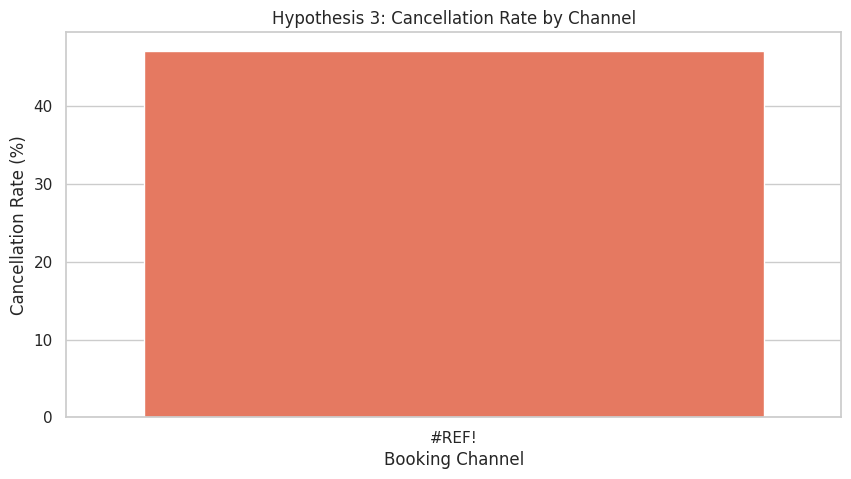

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ตั้งค่าให้กราฟแสดงผลสวยงาม
sns.set_theme(style="whitegrid")

# ==========================================
# 1. โหลดข้อมูล (ใช้แค่ 2 ไฟล์ตามที่กำหนด)
# ==========================================
try:
    df_bookings = pd.read_csv('fact_bookings_5000.csv')
    df_marketing = pd.read_csv('fact_marketing_spend.csv')
    print("✅ โหลดข้อมูลสำเร็จ! กำลังทำความสะอาดและประมวลผลกราฟ...")
except FileNotFoundError:
    print("❌ ไม่พบไฟล์ข้อมูล กรุณาตรวจสอบชื่อไฟล์ในแถบด้านซ้ายมือว่าตรงกับ 'fact_bookings_5000.csv' และ 'fact_marketing_spend.csv' หรือไม่")

# ==========================================
# 🚨 ส่วนที่แก้ไขใหม่: Data Cleaning (แก้ Error Type)
# ==========================================
# คอลัมน์ที่ควรจะเป็นตัวเลขแต่ติดคอมมา (,) ให้ลบคอมมาทิ้งแล้วแปลงเป็นทศนิยม (float)
numeric_cols = ['gross_revenue', 'commission_amount', 'net_revenue']
for col in numeric_cols:
    if df_bookings[col].dtype == 'object': # ถ้ามันมองเห็นเป็นข้อความ
        # บังคับแปลงเป็น string ลบคอมมาออก แล้วแปลงเป็น float
        df_bookings[col] = df_bookings[col].astype(str).str.replace(',', '', regex=True).astype(float)

if df_marketing['cost_amount'].dtype == 'object':
    df_marketing['cost_amount'] = df_marketing['cost_amount'].astype(str).str.replace(',', '', regex=True).astype(float)

# ==========================================
# Hypothesis 1: Net ADR Efficiency (กำไรสุทธิต่อห้อง)
# ==========================================
# กรองเอาเฉพาะรายการที่ Confirmed
df_confirmed = df_bookings[df_bookings['booking_status'].astype(str).str.lower() == 'confirmed']

# คำนวณ Net ADR
net_adr_by_channel = df_confirmed.groupby('Channel Name')['net_revenue'].mean().reset_index()
net_adr_by_channel.rename(columns={'net_revenue': 'Net_ADR'}, inplace=True)
net_adr_by_channel = net_adr_by_channel.sort_values(by='Net_ADR', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=net_adr_by_channel, x='Channel Name', y='Net_ADR', palette='viridis')
plt.title('Hypothesis 1: Net ADR Efficiency by Channel (Confirmed Bookings)')
plt.ylabel('Net ADR (THB)')
plt.xlabel('Booking Channel')
plt.show()

# ==========================================
# Hypothesis 2: Cost of Acquisition (COA %)
# ==========================================
# 1. หาผลรวม Gross Revenue และ Commission
finance_summary = df_bookings.groupby('Channel Name').agg(
    Total_Gross_Revenue=('gross_revenue', 'sum'),
    Total_Commission=('commission_amount', 'sum')
).reset_index()

# 2. หาผลรวม Marketing Spend ของช่องทาง Direct
total_marketing_spend = df_marketing['cost_amount'].sum()

# 3. คำนวณ COA %
def calculate_coa(row):
    if row['Total_Gross_Revenue'] == 0:
        return 0
    if row['Channel Name'] == 'Direct Website':
        total_cost = row['Total_Commission'] + total_marketing_spend
    else:
        total_cost = row['Total_Commission']
    return (total_cost / row['Total_Gross_Revenue']) * 100

finance_summary['COA_Percent'] = finance_summary.apply(calculate_coa, axis=1)
finance_summary = finance_summary.sort_values(by='COA_Percent')

plt.figure(figsize=(10, 5))
sns.barplot(data=finance_summary, x='Channel Name', y='COA_Percent', palette='magma')
plt.title('Hypothesis 2: Cost of Acquisition (COA %) - Lower is Better')
plt.ylabel('COA (%)')
plt.xlabel('Booking Channel')
plt.show()

# ==========================================
# Hypothesis 3: Hidden Costs in Cancellation Rate
# ==========================================
# นับสถานะการจอง (แก้ปัญหาตัวพิมพ์เล็ก/ใหญ่)
df_bookings['status_clean'] = df_bookings['booking_status'].astype(str).str.lower()
status_counts = df_bookings.groupby(['Channel Name', 'status_clean']).size().unstack(fill_value=0)

# เช็คว่ามีคอลัมน์ cancelled หรือไม่ ถ้าไม่มีให้ใส่ 0
if 'cancelled' not in status_counts.columns:
    status_counts['cancelled'] = 0
if 'confirmed' not in status_counts.columns:
    status_counts['confirmed'] = 0

status_counts['Total_Bookings'] = status_counts['confirmed'] + status_counts['cancelled']
status_counts['Cancellation_Rate_Percent'] = (status_counts['cancelled'] / status_counts['Total_Bookings']) * 100

status_counts = status_counts.sort_values(by='Cancellation_Rate_Percent', ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=status_counts, x='Channel Name', y='Cancellation_Rate_Percent', palette='Reds_r')
plt.title('Hypothesis 3: Cancellation Rate by Channel')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Booking Channel')
plt.show()

=== สรุปผล Cost of Acquisition (COA %) ===
  Channel Name  Total_Gross_Revenue  COA_Percent
0        #REF!           12234968.9    14.567839


/tmp/ipykernel_2467/2257531505.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=finance_summary, x='Channel Name', y='COA_Percent', palette='magma')


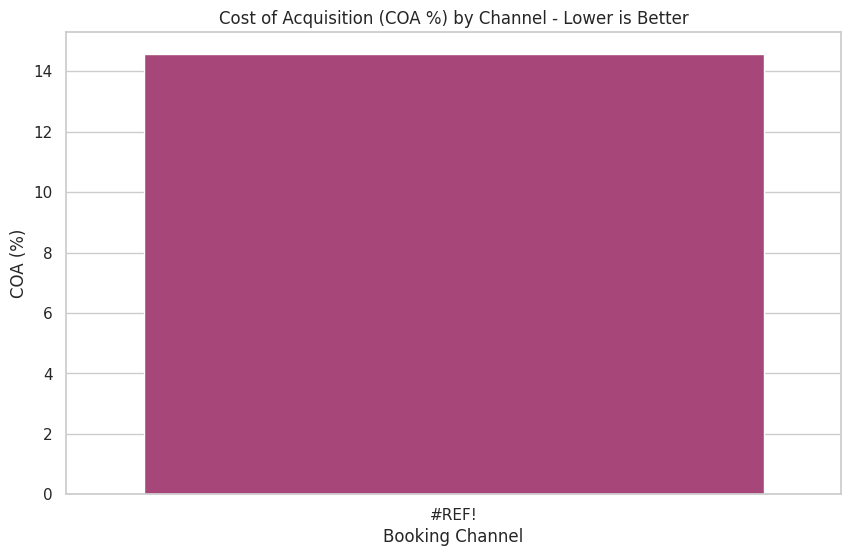

In [4]:
# 1. หาผลรวม Gross Revenue และ Commission ของแต่ละช่องทาง
finance_summary = df_bookings.groupby('Channel Name').agg(
    Total_Gross_Revenue=('gross_revenue', 'sum'),
    Total_Commission=('commission_amount', 'sum')
).reset_index()

# 2. หาผลรวม Marketing Spend (ใช้สำหรับ Direct Website)
total_marketing_spend = df_marketing['cost_amount'].sum()

# 3. สร้างฟังก์ชันคำนวณ COA %
def calculate_coa(row):
    # ถ้ารายได้เป็น 0 ให้ COA เป็น 0 ป้องกัน error
    if row['Total_Gross_Revenue'] == 0:
        return 0

    # ถ้าเป็น Direct Website ให้บวกค่าโฆษณาเข้าไปด้วย
    if row['Channel Name'] == 'Direct Website':
        total_cost = row['Total_Commission'] + total_marketing_spend
    else:
        total_cost = row['Total_Commission'] # OTA เสียแค่คอมมิชชัน

    return (total_cost / row['Total_Gross_Revenue']) * 100

# คอลัมน์ใหม่ COA_Percent
finance_summary['COA_Percent'] = finance_summary.apply(calculate_coa, axis=1)
finance_summary = finance_summary.sort_values(by='COA_Percent')

print("=== สรุปผล Cost of Acquisition (COA %) ===")
print(finance_summary[['Channel Name', 'Total_Gross_Revenue', 'COA_Percent']])

# วาดกราฟ
plt.figure(figsize=(10, 6))
sns.barplot(data=finance_summary, x='Channel Name', y='COA_Percent', palette='magma')
plt.title('Cost of Acquisition (COA %) by Channel - Lower is Better')
plt.ylabel('COA (%)')
plt.xlabel('Booking Channel')
plt.show()

=== สรุปอัตราการยกเลิก (Cancellation Rate %) ===
booking_status Channel Name  Total_Bookings  cancelled  \
0                     #REF!            5000       2359   

booking_status  Cancellation_Rate_Percent  
0                                   47.18  


/tmp/ipykernel_2467/3110936233.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=status_counts, x='Channel Name', y='Cancellation_Rate_Percent', palette='Reds_r')


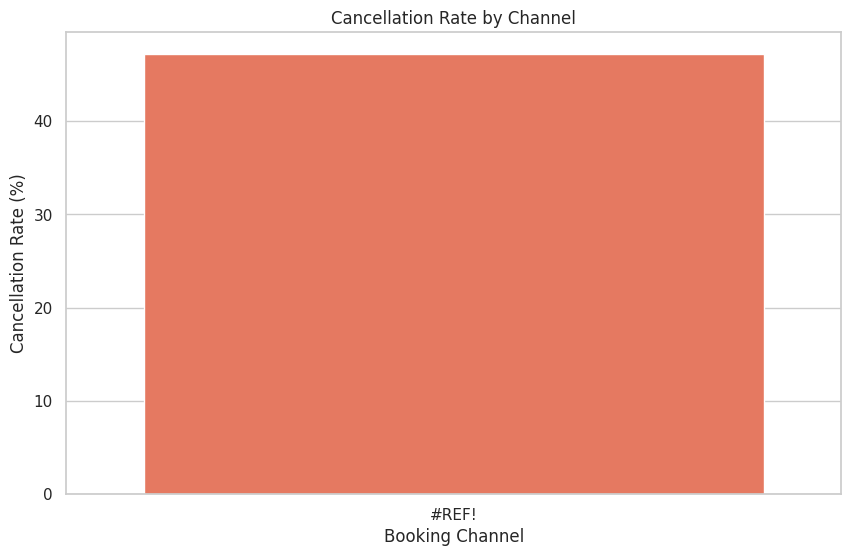

In [5]:
# นับจำนวนสถานะการจองแบ่งตามช่องทาง
status_counts = df_bookings.groupby(['Channel Name', 'booking_status']).size().unstack(fill_value=0)

# สร้างคอลัมน์คำนวณอัตราการยกเลิก
status_counts['Total_Bookings'] = status_counts['confirmed'] + status_counts['cancelled']
status_counts['Cancellation_Rate_Percent'] = (status_counts['cancelled'] / status_counts['Total_Bookings']) * 100

status_counts = status_counts.sort_values(by='Cancellation_Rate_Percent', ascending=False).reset_index()

print("=== สรุปอัตราการยกเลิก (Cancellation Rate %) ===")
print(status_counts[['Channel Name', 'Total_Bookings', 'cancelled', 'Cancellation_Rate_Percent']])

# วาดกราฟอัตราการยกเลิก
plt.figure(figsize=(10, 6))
sns.barplot(data=status_counts, x='Channel Name', y='Cancellation_Rate_Percent', palette='Reds_r')
plt.title('Cancellation Rate by Channel')
plt.ylabel('Cancellation Rate (%)')
plt.xlabel('Booking Channel')
plt.show()